
## Lab1_2: Seaborn (From Matplolib and pandas to seaborn)

In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Laboratorio_1.2
* Hacer el analisis estadístico de las variables: Millas por galón (mpg) vs potencia (horsepower) in the dataset: millas_por_galón.csv. Contruya el fit de al $95$ C.L.     



  



In [2]:
# Vamos a cargarlos desde "local", aunque creo que es un dataset de ejemplo de SNS.
df = pd.read_csv(r"C:\Proyectos\Fisica-com\Fisica_Computacional_1\Sesiones\seaborn\millas_por_galon.csv")
# Muestro la cabeza del dataset pa' ver qué es lo que tiene
print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  


In [3]:
# Qué carros tan bonitos los clásicos, se puede uno quedar toda la tarde viéndolos y estudiándolos...
# Me quedo con las variables que voy a analizar. Pongo el método .dropna() para quitar (si es que los hay)
# los valores Nan en el dataset, es una buena práctica para evitar problemas.
df = df[["mpg","horsepower"]].dropna()
# Dado que queremos hacer un análisis estadísitico de las variables, nos podemos ayudar de sus valores
# estadísticos descriptivos
df.describe()
# Esto nos muestra el número de datos, la media, la desviación estánda,r los cuartiles y valores máximos.
# Es útil si quisiéramos hacer el análisis de cada variable

,mpg,horsepower
count,392.000000,392.000000
mean,23.445918,104.469388
std,7.805007,38.491160
min,9.000000,46.000000
25%,17.000000,75.000000
50%,22.750000,93.500000
75%,29.000000,126.000000
max,46.600000,230.000000


In [4]:
# Para entender mejor la depencia entre MPG y horsepower, podemos calcular la matriz de correlación
# entre estas dos variables. Por supuesto, es simétrica y 1 en la diagonal.
df.corr()
# el valor -0.778427 de por sí da una idea de posible dependencia entre las variables.
# Por lo general, un menor mpg resulta en un mayor horsepower (o viceversa)

,mpg,horsepower
mpg,1.000000,-0.778427
horsepower,-0.778427,1.000000


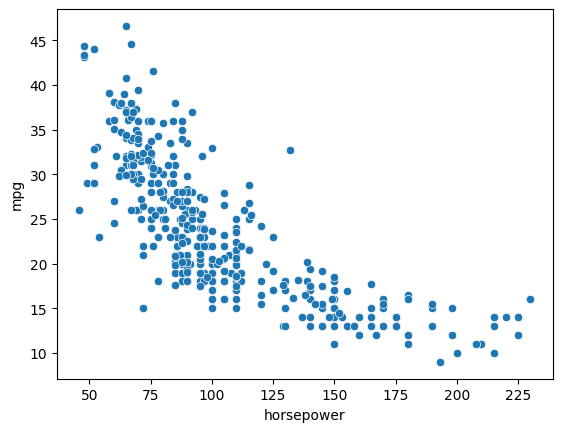

In [5]:
# Para tratar de dar con un comportamiento de los datos,
# Vamos a visualizarlos con SNS
sns.scatterplot(data=df, x="horsepower", y="mpg")
plt.show()

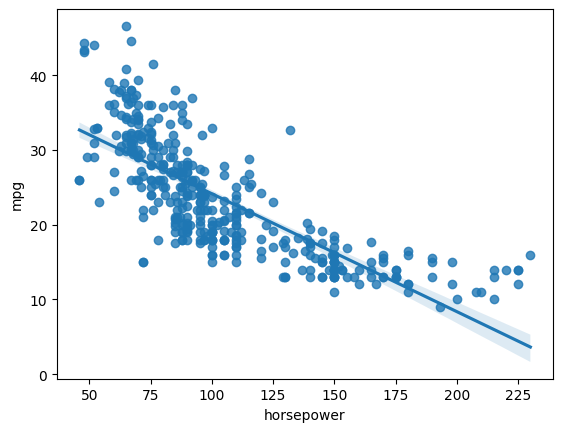

In [6]:
# Por la distribución de los puntos, es "claro" (ese es claro en estadística es relativo)
# que hay una dependencia entre los datos, que ya apuntaba la correlación mostrada anteriormente. 
# Podemos analizar qué tan bien se ajusta un modelo lineal a estos datos.

# SNS hace un fitteo lineal (se puede poner polinomial) a los datos,
sns.regplot(
    data=df,
    x="horsepower",
    y="mpg",
    ci=95 # Este es el intervalo de confianza, puesto al 95. (Confidence Interval)
)
plt.show()
# Parece que un fiteo lineal no es lo apropiado, tratemos de dar argumentos a esto

In [7]:
import statsmodels.api as sm
# Primero, podemos hacer un análisis estadísico con la librería 
# statsmodels, que da un resumen muy bueno para la regresión lineal
# Inicialmente se crea el modelo más sencillo, x = a . y
# Sumamos una contante para tener un modelo afín x = a . y + b
X = sm.add_constant(df["horsepower"])

# Aquí hacemos el fitteo lineal
model = sm.OLS(df["mpg"], X).fit()

print(model.summary())
# Hay una gran cantidad de info que muestra: el valor de pendiente (-0.16),
# el del intercepto (39.94), el intervalo de confianza, al 95%, de cada parámetro, 
# un coeficiente de determinación R^2=0.606, lo que implica que aproximadamente 
# el 60.6% de la variabilidad observada en mpg es explicada por la potencia.
# La pendiente estimada resultó estadísticamente significativa (p < 0.001).
# Estos resultados sugieren una relación inversa robusta entre potencia y 
# eficiencia energética en el conjunto de datos analizado.


                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     599.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           7.03e-81
Time:                        19:38:58   Log-Likelihood:                -1178.7
No. Observations:                 392   AIC:                             2361.
Df Residuals:                     390   BIC:                             2369.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.9359      0.717     55.660      0.0

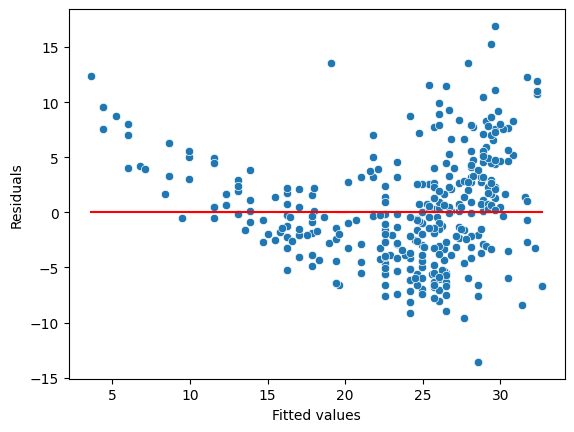

In [8]:
# También podemos mostrar una gráfica de residuos; si observamos un patrón en la distribución, 
# no unos residuos uniformes alrededor de cero, buscamos otro modelo
y_pred = model.fittedvalues
res = model.resid

sns.scatterplot(x=y_pred, y=res)
sns.lineplot(x=y_pred, y=[0]*len(y_pred), color="red")

plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()
# Claramente no hay una  distribución uniforme alrededor del 0

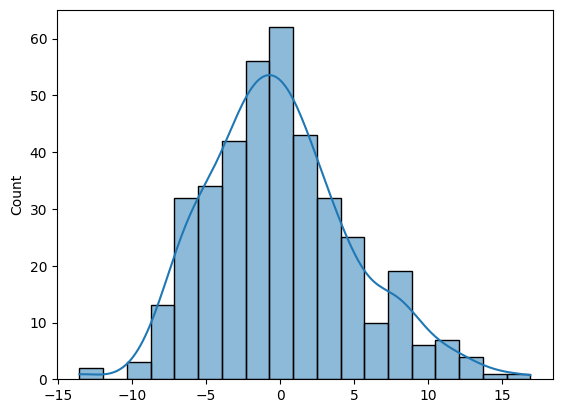

In [9]:
# Para analizar mejor el comportamiento de los residuos se muestra el histograma que producen.
# Para una gaussiana un poco desviada, aunque es satisfactorio que la moda esté en 0, 
# el hecho de que tenga tan alta desviación estándar sugiere que el modelo lineal no es el
# adecuado.
sns.histplot(res, kde=True)
plt.show()

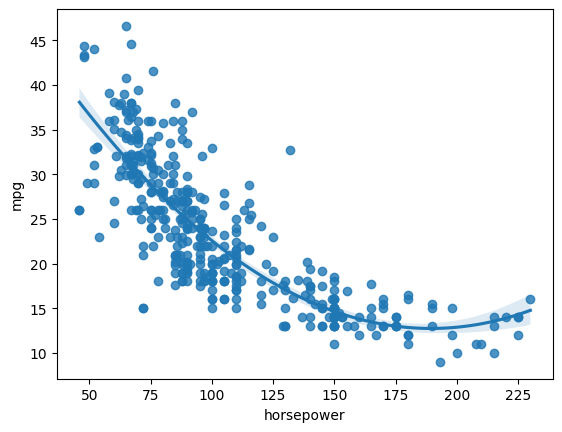

In [10]:
# Podemos probar un ajuste cuadrático
sns.regplot(
    data=df,
    x="horsepower",
    y="mpg",
    order=2,
    ci=95
)
plt.show()
# Visualmente parece mejor
# Creo que podemos dejar hasta aquí el análisis. Mostramos suficientes herramientas para un análisis estadítico a mi parecer.

nota 5. buen trabajo